## Polynomial Regression

Polynomial Regression is an extension of Linear Regression that models nonlinear relationships by adding polynomial terms such as x2, x3, etc. The model is still considered linear because it remains linear in its coefficients. It helps capture curved patterns in data but may overfit if the polynomial degree is too high.

In [106]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [4]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

# y = 0.8x^2 + 0.9x + 2

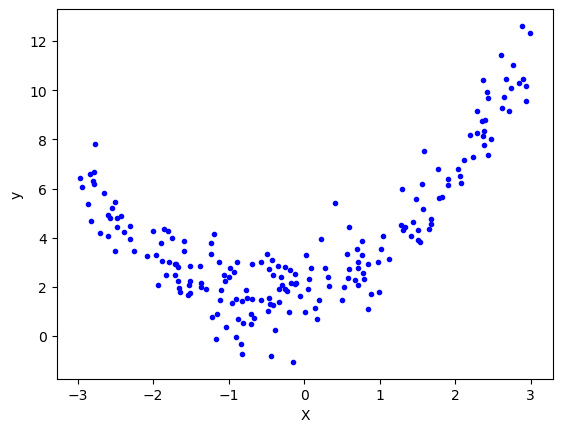

In [6]:
plt.plot(X, y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [8]:
# Train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [22]:
# Applying linear regression
lr = LinearRegression()

In [24]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
y_pred = lr.predict(X_test)
lr_R2_Score = r2_score(y_test, y_pred)
print("R2_score",lr_R2_Score)

R2_score 0.26289659783303676


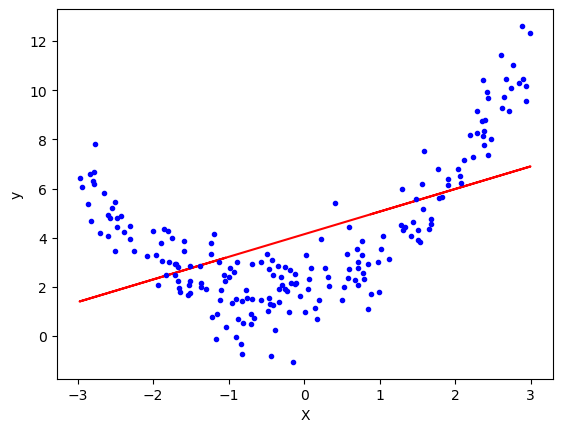

In [30]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [32]:
#  let's create a polynomial feature object with degree 2. 
degree = 2  # Degree of the polynomial
poly_features = PolynomialFeatures(degree=degree, include_bias=True)

In [34]:
# ONLY fit the poly features on training data, then transfor
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

In [36]:
print(X_train[0])
print(X_train_poly[0])

[0.88537356]
[1.         0.88537356 0.78388634]


In [38]:
# Model training
# Train the model ONLY on training data
lr_model = LinearRegression()
#Now, fit the model (linear regression object) on the data
lr_model.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
y_pred_poly = lr_model.predict(X_test_poly)

In [44]:
poly_R2_Score = r2_score(y_test,y_pred_poly)
print("R2_score",poly_R2_Score)

R2_score 0.8460426380741249


In [46]:
print(lr_model.coef_)
print(lr_model.intercept_)

[[0.         0.83929446 0.81335022]]
[1.8924589]


In [48]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lr_model.predict(X_new_poly)

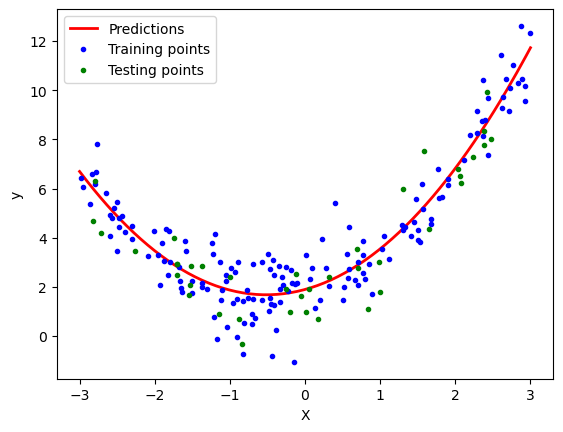

In [50]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [56]:
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly_features.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

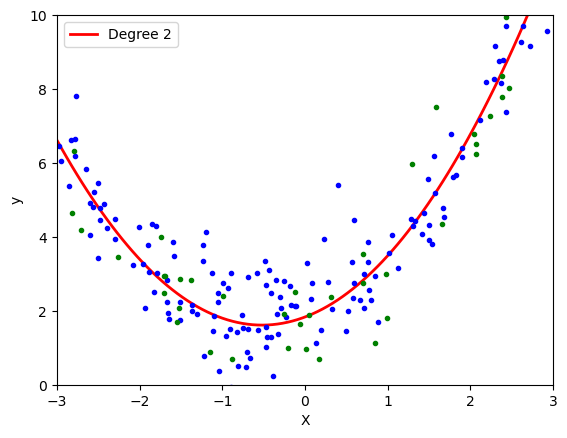

In [80]:
polynomial_regression(2)

In [72]:
poly_features.powers_

array([[0],
       [1],
       [2]])

## 3D Polynomial Regression

In [84]:
# 3D polynomial regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

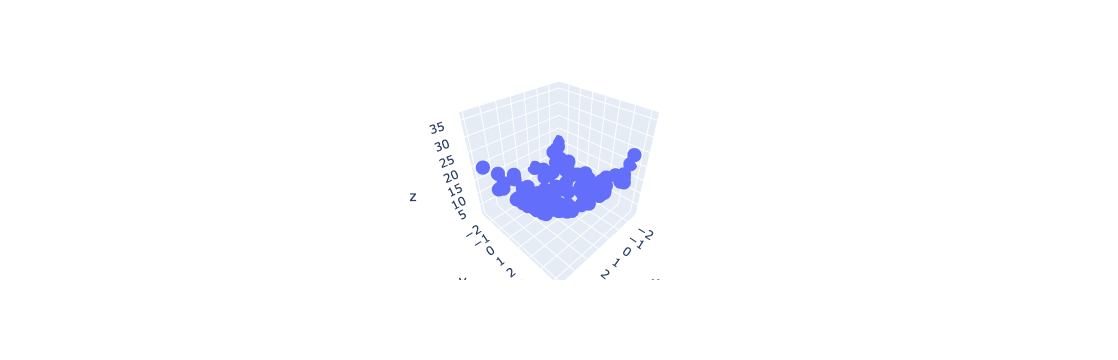

In [88]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [116]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

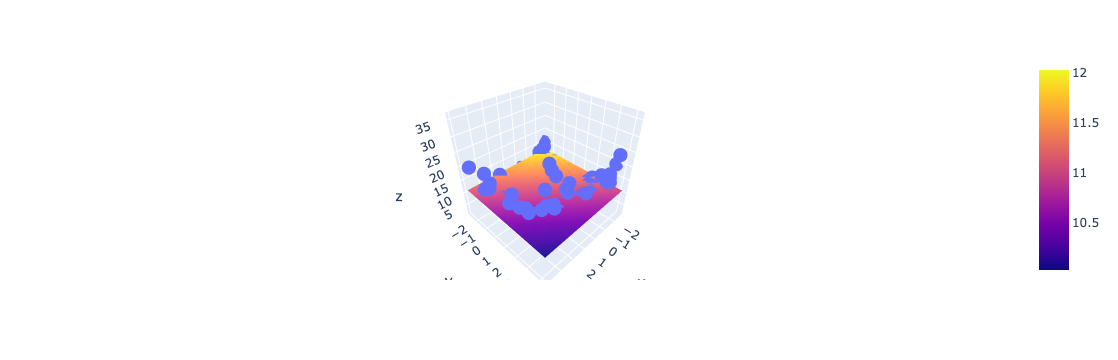

In [118]:
import plotly.graph_objects as go

fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

In [120]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [144]:
poly = PolynomialFeatures(degree=3)
X_multi_trans = poly.fit_transform(X_multi)

In [146]:
print("Input",poly.n_features_in_)
print("Ouput",poly.n_output_features_)
print("Powers\n",poly.powers_)

Input 2
Ouput 10
Powers
 [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]
 [3 0]
 [2 1]
 [1 2]
 [0 3]]


In [148]:
X_multi_trans.shape

(100, 10)

In [150]:
lr = LinearRegression()
lr.fit(X_multi_trans,z)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [152]:
X_test_multi = poly.transform(final)

In [154]:
z_final = lr.predict(X_multi_trans).reshape(10,10)

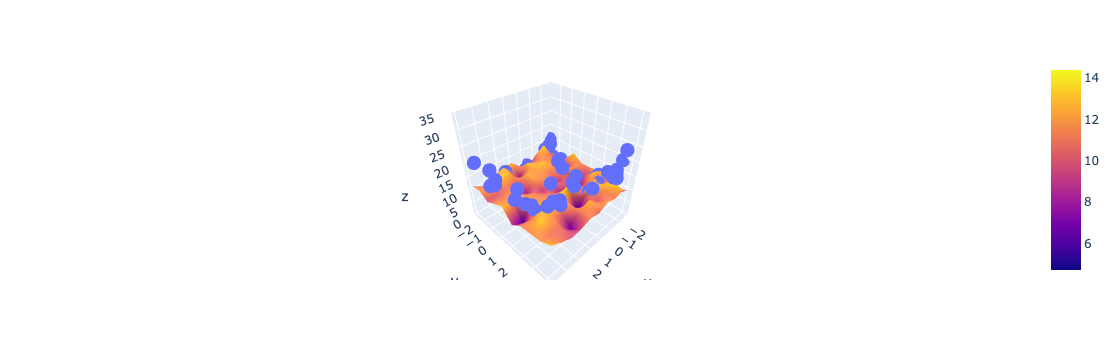

In [155]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()